2026-01-08 18:35:49.896573: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767897350.081431      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767897350.132433      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767897350.562575      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767897350.562627      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767897350.562631      55 computation_placer.cc:177] computation placer alr

🚀 APTOS 2019 DR SCREENING SYSTEM

DIABETIC RETINOPATHY SCREENING SYSTEM (APTOS 2019)

Task:
Binary diabetic retinopathy screening. Grade 0 = HEALTHY, grades 1–4 = DISEASED.

Model:
EfficientNetB3 (ImageNet pretraining) + custom sigmoid head.

Training:
Two-phase transfer learning:
(1) Train head with base frozen
(2) Fine-tune later layers while freezing early layers.

Imbalance:
Focal loss (gamma=2.0, alpha=0.80) + class weights.

Operating Threshold:
Selected via ROC to satisfy target sensitivity/recall for diseased class (>= 0.90),
then maximize accuracy among feasible thresholds.

Calibration:
Post-hoc calibration on a held-out calibration split:
- Temperature scaling
- Platt scaling
Best calibration is selected by accuracy under recall constraint.

Explainability:
Grad-CAM heatmaps highlight salient image regions driving DISEASED predictions.

✅ Loaded 3662 images (detected extension: .png)
   HEALTHY (0):  1805 (49.3%)
   DISEASED (1): 1857 (50.7%)

Train samples:      2563
Calib 

I0000 00:00:1767897364.048154      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


⚖️ Class weights: HEALTHY=1.015, DISEASED=0.986

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Model Summary:


Model: "aptos_effb3_binary"

...


PHASE 1: TRAIN HEAD (BASE FROZEN)

Epoch 1/20


E0000 00:00:1767897388.584241      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/aptos_effb3_binary_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1767897462.580326     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.7221 - auc: 0.7946 - loss: 0.1276 - recall: 0.5971
Epoch 1: val_recall improved from -inf to 0.83513, saving model to /kaggle/working/best_model.keras
161/161 ━━━━━━━━━━━━━━━━━━━━ 141s 303ms/step - accuracy: 0.7226 - auc: 0.7952 - loss: 0.1272 - recall: 0.5979 - val_accuracy: 0.9036 - val_auc: 0.9800 - val_loss: 0.0245 - val_recall: 0.8351 - learning_rate: 1.0000e-04
Epoch 2/20
160/161 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.8982 - auc: 0.9575 - loss: 0.0235 - recall: 0.8820
Epoch 2: val_recall improved from 0.83513 to 0.93907, saving model to /kaggle/working/best_model.keras
161/161 ━━━━━━━━━━━━━━━━━━━━ 103s 264ms/step - accuracy: 0.8982 - auc: 0.9575 - loss: 0.0235 - recall: 0.8820 - val_accuracy: 0.9400 - val_auc: 0.9871 - val_loss: 0.0081 - val_recall: 0.9391 - learning_rate: 1.0000e-04
Epoch 3/20
160/161 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.9158 - auc: 0.9678 - loss: 0.0174 - recall: 0.8998
Epoch 3: val_

E0000 00:00:1767898658.193778      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/aptos_effb3_binary_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.8086 - auc: 0.8949 - loss: 0.0532 - recall: 0.8213
Epoch 1: val_recall improved from -inf to 0.77778, saving model to /kaggle/working/best_model.keras
161/161 ━━━━━━━━━━━━━━━━━━━━ 159s 364ms/step - accuracy: 0.8088 - auc: 0.8950 - loss: 0.0531 - recall: 0.8214 - val_accuracy: 0.8855 - val_auc: 0.9761 - val_loss: 0.0341 - val_recall: 0.7778 - learning_rate: 1.0000e-05
Epoch 2/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.8824 - auc: 0.9534 - loss: 0.0260 - recall: 0.8812
Epoch 2: val_recall did not improve from 0.77778
161/161 ━━━━━━━━━━━━━━━━━━━━ 111s 319ms/step - accuracy: 0.8824 - auc: 0.9534 - loss: 0.0260 - recall: 0.8812 - val_accuracy: 0.8836 - val_auc: 0.9793 - val_loss: 0.0334 - val_recall: 0.7778 - learning_rate: 1.0000e-05
Epoch 3/15
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.8894 - auc: 0.9566 - loss: 0.0255 - recall: 0.8751
Epoch 3: val_recall improved from 0.77778 to 0.79928, saving model 

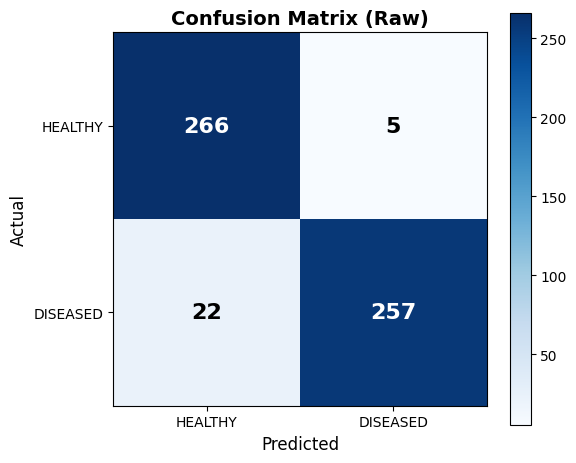


CALIBRATION FIT (on CALIB split only)
🌡️ Fitted Temperature T = 1.6828
✅ Fitted Platt scaler

EVALUATING CALIBRATED MODES (on VAL)

📊 ROC AUC (temp): 0.9889
📋 Threshold info (temp): {'threshold': 0.2666875123977661, 'accuracy': 0.9509090909090909, 'recall': 0.921146953405018, 'tpr': 0.921146953405018, 'fpr': 0.01845018450184502}

TEMPERATURE-CALIBRATED (ROC Threshold)
Threshold: 0.2667
Accuracy:  0.9509
Recall (DISEASED): 0.9211

              precision    recall  f1-score   support

     HEALTHY     0.9236    0.9815    0.9517       271
    DISEASED     0.9809    0.9211    0.9501       279

    accuracy                         0.9509       550
   macro avg     0.9523    0.9513    0.9509       550
weighted avg     0.9527    0.9509    0.9509       550



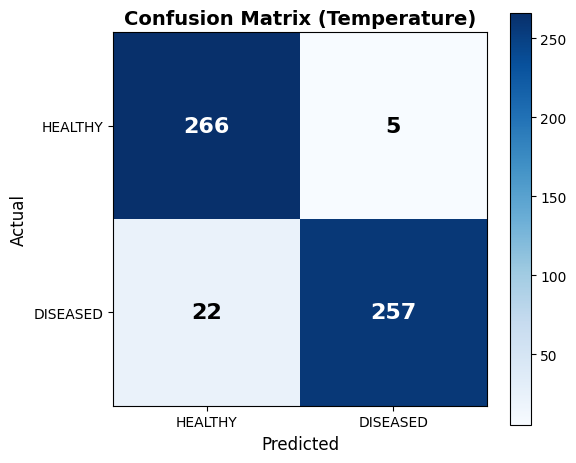


📊 ROC AUC (platt): 0.9889
📋 Threshold info (platt): {'threshold': 0.7752497083899509, 'accuracy': 0.9509090909090909, 'recall': 0.921146953405018, 'tpr': 0.921146953405018, 'fpr': 0.01845018450184502}

PLATT-CALIBRATED (ROC Threshold)
Threshold: 0.7752
Accuracy:  0.9509
Recall (DISEASED): 0.9211

              precision    recall  f1-score   support

     HEALTHY     0.9236    0.9815    0.9517       271
    DISEASED     0.9809    0.9211    0.9501       279

    accuracy                         0.9509       550
   macro avg     0.9523    0.9513    0.9509       550
weighted avg     0.9527    0.9509    0.9509       550



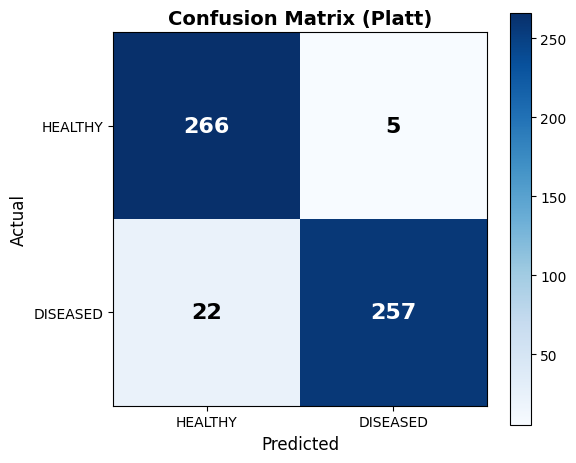


🎯 SELECTED OPERATING MODE
Mode:      RAW
Threshold: 0.1542
Accuracy:  0.9509
Recall:    0.9211

🔍 Generating up to 6 Grad-CAM examples...

Using last conv layer: top_conv



KeyError: "Exception encountered when calling Functional.call().\n\n\x1b[1m133897615108688\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=tf.Tensor(shape=(1, 300, 300, 3), dtype=float32)\n  • training=False\n  • mask=None\n  • kwargs=<class 'inspect._empty'>"

In [1]:
"""
APTOS 2019 DR Screening - Complete Kaggle System (Robust + Fast)
Dataset: /kaggle/input/effiecieeeeeeentnetb
- EfficientNetB3 + Focal Loss
- Class weights
- 2-phase transfer learning
- ROC-based threshold selection (target recall)
- Proper calibration split (Temperature + Platt)
- Grad-CAM explanations (Keras3-safe via inference-only model)
- Saves: best_model.keras, final_model.keras, threshold.json, temp.json, platt.json
"""

# =========================================================
# FIXES / ENV (set BEFORE TensorFlow import)
# =========================================================
import os
os.environ["TF_ENABLE_LAYOUT_OPTIMIZER"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import json
import glob
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB3
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, recall_score, classification_report,
    confusion_matrix, roc_curve, auc
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# =========================================================
# CONFIG
# =========================================================
CONFIG = {
    "base_path": "/kaggle/input/effiecieeeeeeentnetb",   # your uploaded dataset
    "csv_name": "train.csv",
    "img_dir_name": "train_images",

    "img_size": 300,
    "batch_size": 16,
    "seed": 42,

    # Training
    "phase1_epochs": 20,
    "phase1_lr": 1e-4,

    "phase2_epochs": 15,
    "phase2_lr": 1e-5,
    "freeze_until_layer": 200,  # freeze early layers in phase2

    # Focal loss
    "focal_gamma": 2.0,
    "focal_alpha": 0.80,

    # Operating point
    "target_recall": 0.90,

    # Temperature scaling
    "temp_lr": 0.05,
    "temp_steps": 300,

    # Grad-CAM
    "gradcam_alpha": 0.40,
    "gradcam_examples": 6,

    # Output paths
    "out_dir": "/kaggle/working",
    "best_model_path": "/kaggle/working/best_model.keras",
    "final_model_path": "/kaggle/working/aptos_dr_final.keras",
    "threshold_path": "/kaggle/working/threshold.json",
    "temp_path": "/kaggle/working/temp.json",
    "platt_path": "/kaggle/working/platt.json",
}

os.makedirs(CONFIG["out_dir"], exist_ok=True)

tf.random.set_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])

# =========================================================
# PAPER-READY EXPLANATION (printed once)
# =========================================================
PAPER_EXPLANATION = """
DIABETIC RETINOPATHY SCREENING SYSTEM (APTOS 2019)

Task:
Binary diabetic retinopathy screening. Grade 0 = HEALTHY, grades 1–4 = DISEASED.

Model:
EfficientNetB3 (ImageNet pretraining) + custom sigmoid head.

Training:
Two-phase transfer learning:
(1) Train head with base frozen
(2) Fine-tune later layers while freezing early layers.

Imbalance:
Focal loss (gamma=2.0, alpha=0.80) + class weights.

Operating Threshold:
Selected via ROC to satisfy target sensitivity/recall for diseased class (>= 0.90),
then maximize accuracy among feasible thresholds.

Calibration:
Post-hoc calibration on a held-out calibration split:
- Temperature scaling
- Platt scaling
Best calibration is selected by accuracy under recall constraint.

Explainability:
Grad-CAM heatmaps highlight salient image regions driving DISEASED predictions.
""".strip()

# =========================================================
# FOCAL LOSS (binary)
# =========================================================
def focal_loss(gamma=2.0, alpha=0.80):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(tf.cast(y_pred, tf.float32), 1e-7, 1 - 1e-7)
        bce = keras.losses.binary_crossentropy(y_true, y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_true) * 0 + (1 - y_true) * (1 - y_pred)
        # The line above is equivalent to: p_t = y_true*y_pred + (1-y_true)*(1-y_pred)
        # kept expanded to avoid accidental dtype casts in some environments.
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        return alpha * tf.pow(1 - p_t, gamma) * bce
    return loss

# =========================================================
# FAST DATA LOADING (NO per-row os.path.exists)
# =========================================================
def detect_extension_and_build_paths(df, img_dir):
    """
    Efficiently detect whether images are .png or .jpeg (or .jpg) by scanning directory once,
    then build paths without per-row exists checks.
    """
    # Build a set of available basenames from directory scan (fast)
    png_files  = glob.glob(os.path.join(img_dir, "*.png"))
    jpeg_files = glob.glob(os.path.join(img_dir, "*.jpeg"))
    jpg_files  = glob.glob(os.path.join(img_dir, "*.jpg"))

    ext = None
    if len(png_files) > 0:
        ext = ".png"
        available = set(os.path.splitext(os.path.basename(f))[0] for f in png_files)
    elif len(jpeg_files) > 0:
        ext = ".jpeg"
        available = set(os.path.splitext(os.path.basename(f))[0] for f in jpeg_files)
    elif len(jpg_files) > 0:
        ext = ".jpg"
        available = set(os.path.splitext(os.path.basename(f))[0] for f in jpg_files)
    else:
        raise FileNotFoundError(f"❌ No images found in {img_dir} (expected png/jpeg/jpg)")

    # Filter to those that actually exist (set membership, fast)
    df = df[df["id_code"].astype(str).isin(available)].copy()
    df["path"] = df["id_code"].astype(str).apply(lambda x: os.path.join(img_dir, f"{x}{ext}"))

    return df, ext

def load_aptos_dataframe(config):
    csv_path = os.path.join(config["base_path"], config["csv_name"])
    img_dir  = os.path.join(config["base_path"], config["img_dir_name"])

    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"❌ train.csv not found: {csv_path}")
    if not os.path.exists(img_dir):
        raise FileNotFoundError(f"❌ train_images not found: {img_dir}")

    df = pd.read_csv(csv_path)
    if "id_code" not in df.columns or "diagnosis" not in df.columns:
        raise ValueError("❌ train.csv must contain columns: id_code, diagnosis")

    # Binary labels
    df["label"] = (df["diagnosis"] > 0).astype(int)

    # Detect ext and build paths efficiently
    df, ext = detect_extension_and_build_paths(df, img_dir)
    df = df.reset_index(drop=True)

    if len(df) == 0:
        raise ValueError("❌ No valid images matched train.csv ids in train_images.")

    print(f"✅ Loaded {len(df)} images (detected extension: {ext})")
    print(f"   HEALTHY (0):  {(df['label']==0).sum()} ({(df['label']==0).sum()/len(df)*100:.1f}%)")
    print(f"   DISEASED (1): {(df['label']==1).sum()} ({(df['label']==1).sum()/len(df)*100:.1f}%)\n")
    return df

# =========================================================
# TF.DATA (stable decode)
# =========================================================
def decode_image(path, label, img_size):
    img_bytes = tf.io.read_file(path)

    # Decode based on extension (png/jpg/jpeg)
    # We branch by file suffix for speed & shape stability.
    path_lower = tf.strings.lower(path)
    is_png = tf.strings.regex_full_match(path_lower, ".*\\.png")
    img = tf.cond(
        is_png,
        lambda: tf.image.decode_png(img_bytes, channels=3),
        lambda: tf.image.decode_jpeg(img_bytes, channels=3),
    )
    img.set_shape([None, None, 3])

    img = tf.image.resize(img, (img_size, img_size), method="bilinear")
    img = tf.cast(img, tf.float32)  # keep [0..255] float; preprocess_input inside model
    return img, tf.cast(label, tf.float32)

def augmentation_layer():
    return keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomFlip("vertical"),
        layers.RandomRotation(0.25),
        layers.RandomZoom(0.20),
        layers.RandomTranslation(0.10, 0.10),
        layers.RandomContrast(0.25),
        layers.RandomBrightness(0.20),
    ], name="augmentation")

def make_dataset(df, config, training=True):
    ds = tf.data.Dataset.from_tensor_slices((df["path"].values, df["label"].values))
    ds = ds.map(lambda p, y: decode_image(p, y, config["img_size"]),
                num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(2048, seed=config["seed"], reshuffle_each_iteration=True)
    ds = ds.batch(config["batch_size"]).prefetch(tf.data.AUTOTUNE)
    return ds

# =========================================================
# MODEL
# =========================================================
def build_model(config):
    inputs = layers.Input(shape=(config["img_size"], config["img_size"], 3), name="input_img")
    x = augmentation_layer()(inputs)
    x = tf.keras.applications.efficientnet.preprocess_input(x)

    base = EfficientNetB3(weights="imagenet", include_top=False, pooling="avg")
    base.trainable = False

    x = base(x, training=False)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.50)(x)
    outputs = layers.Dense(1, activation="sigmoid", name="prob")(x)

    model = keras.Model(inputs, outputs, name="aptos_effb3_binary")
    return model, base

# =========================================================
# CLASS WEIGHTS
# =========================================================
def compute_class_weights_dict(df):
    labels = df["label"].values
    weights = compute_class_weight("balanced", classes=np.unique(labels), y=labels)
    cw = {i: float(w) for i, w in enumerate(weights)}
    print(f"⚖️ Class weights: HEALTHY={cw.get(0, 1.0):.3f}, DISEASED={cw.get(1, 1.0):.3f}\n")
    return cw

# =========================================================
# TRAINING (with checkpoint)
# =========================================================
def make_callbacks(best_path):
    return [
        keras.callbacks.ModelCheckpoint(
            best_path,
            monitor="val_recall",
            mode="max",
            save_best_only=True,
            verbose=1
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_recall",
            mode="max",
            patience=6,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-7,
            verbose=1
        ),
    ]

def train_phase1(model, train_ds, val_ds, class_weights, config):
    print("="*80)
    print("PHASE 1: TRAIN HEAD (BASE FROZEN)")
    print("="*80 + "\n")

    model.compile(
        optimizer=keras.optimizers.Adam(config["phase1_lr"]),
        loss=focal_loss(config["focal_gamma"], config["focal_alpha"]),
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc"),
        ]
    )

    model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=config["phase1_epochs"],
        class_weight=class_weights,
        callbacks=make_callbacks(config["best_model_path"]),
        verbose=1
    )

def train_phase2(model, base, train_ds, val_ds, class_weights, config):
    print("\n" + "="*80)
    print("PHASE 2: FINE-TUNE (PARTIAL UNFREEZE)")
    print("="*80 + "\n")

    base.trainable = True
    for layer in base.layers[:config["freeze_until_layer"]]:
        layer.trainable = False

    trainable = int(np.sum([tf.size(w).numpy() for w in model.trainable_weights]))
    print(f"Trainable parameters: {trainable:,}\n")

    model.compile(
        optimizer=keras.optimizers.Adam(config["phase2_lr"]),
        loss=focal_loss(config["focal_gamma"], config["focal_alpha"]),
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc"),
        ]
    )

    model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=config["phase2_epochs"],
        class_weight=class_weights,
        callbacks=make_callbacks(config["best_model_path"]),
        verbose=1
    )

# =========================================================
# ROC THRESHOLD + REPORTING
# =========================================================
def collect_probs(model, ds, max_images_for_gradcam=10):
    y_true, y_prob = [], []
    images_buf = []
    collected = 0

    for x, y in ds:
        probs = model.predict(x, verbose=0).ravel()
        y_true.extend(y.numpy().astype(int))
        y_prob.extend(probs)

        if collected < max_images_for_gradcam:
            to_take = min(len(x), max_images_for_gradcam - collected)
            images_buf.append(x.numpy()[:to_take])
            collected += to_take

    images = np.concatenate(images_buf, axis=0) if images_buf else None
    return np.array(y_true), np.array(y_prob), images

def roc_threshold_for_target_recall(y_true, y_prob, target_recall=0.90):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    idx = np.where(tpr >= target_recall)[0]
    if len(idx) == 0:
        j = tpr - fpr
        best_i = int(np.argmax(j))
        return float(thresholds[best_i]), float(roc_auc), {
            "note": "Target recall unreachable, using Youden's J",
            "threshold": float(thresholds[best_i]),
            "tpr": float(tpr[best_i]),
            "fpr": float(fpr[best_i]),
        }

    best = None
    for i in idx:
        t = thresholds[i]
        y_pred = (y_prob >= t).astype(int)
        acc = accuracy_score(y_true, y_pred)
        rec = recall_score(y_true, y_pred)
        if best is None or acc > best["accuracy"]:
            best = {
                "threshold": float(t),
                "accuracy": float(acc),
                "recall": float(rec),
                "tpr": float(tpr[i]),
                "fpr": float(fpr[i]),
            }

    return best["threshold"], float(roc_auc), best

def report_metrics(y_true, y_prob, threshold, title="Metrics"):
    y_pred = (y_prob >= threshold).astype(int)
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)

    print("\n" + "="*80)
    print(title)
    print("="*80)
    print(f"Threshold: {threshold:.4f}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Recall (DISEASED): {rec:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=["HEALTHY", "DISEASED"], digits=4))
    return y_pred, acc, rec

def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, cmap="Blues")
    plt.title(title, fontsize=14, fontweight="bold")
    plt.colorbar()
    plt.xticks([0, 1], ["HEALTHY", "DISEASED"])
    plt.yticks([0, 1], ["HEALTHY", "DISEASED"])
    for i in range(2):
        for j in range(2):
            color = "white" if cm[i, j] > cm.max()/2 else "black"
            plt.text(j, i, str(cm[i, j]), ha="center", va="center",
                     color=color, fontsize=16, fontweight="bold")
    plt.ylabel("Actual", fontsize=12)
    plt.xlabel("Predicted", fontsize=12)
    plt.tight_layout()
    plt.show()

# =========================================================
# CALIBRATION (with held-out calibration split)
# =========================================================
def build_logits_model_from_sigmoid(model):
    last = model.layers[-1]
    if not isinstance(last, keras.layers.Dense):
        raise ValueError("Expected final Dense layer as last layer.")
    w, b = last.get_weights()
    penultimate = model.layers[-2].output
    logits = keras.layers.Dense(1, activation=None, name="logits_layer")(penultimate)
    logits_model = keras.Model(inputs=model.input, outputs=logits)
    logits_model.get_layer("logits_layer").set_weights([w, b])
    return logits_model

def fit_temperature(logits, y_true, lr=0.05, steps=300):
    logits_tf = tf.constant(logits.reshape(-1, 1), dtype=tf.float32)
    y_tf = tf.constant(y_true.reshape(-1, 1), dtype=tf.float32)

    T = tf.Variable(1.0, dtype=tf.float32)
    opt = tf.keras.optimizers.Adam(lr)

    for _ in range(steps):
        with tf.GradientTape() as tape:
            scaled = logits_tf / T
            loss = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(labels=y_tf, logits=scaled))
        grads = tape.gradient(loss, [T])
        opt.apply_gradients(zip(grads, [T]))
        T.assign(tf.maximum(T, 1e-3))

    return float(T.numpy())

def apply_temperature_scaling(logits, T):
    return 1.0 / (1.0 + np.exp(-(logits / T)))

def fit_platt_scaler(logits, y_true):
    clf = LogisticRegression(solver="lbfgs", max_iter=1000)
    clf.fit(logits.reshape(-1, 1), y_true)
    return clf

def apply_platt_scaler(platt_model, logits):
    return platt_model.predict_proba(logits.reshape(-1, 1))[:, 1]

# =========================================================
# GRAD-CAM (Keras3-safe: inference-only model)
# =========================================================
def build_inference_model_no_aug(trained_model, img_size=300):
    """
    Rebuild a clean inference model without augmentation to avoid Keras graph issues:
    input -> preprocess -> base -> head layers (reused).
    """
    # Find EfficientNet base (nested model)
    base = None
    for layer in trained_model.layers:
        if isinstance(layer, tf.keras.Model) and "efficientnet" in layer.name.lower():
            base = layer
            break
    if base is None:
        for layer in trained_model.layers:
            if isinstance(layer, tf.keras.Model) and "efficientnet" in layer.__class__.__name__.lower():
                base = layer
                break
    if base is None:
        raise ValueError("Could not locate EfficientNet base inside the trained model.")

    inp = tf.keras.Input(shape=(img_size, img_size, 3), name="infer_input")
    x = tf.keras.applications.efficientnet.preprocess_input(inp)
    feat = base(x, training=False)

    # Reuse head layers from trained model (after base)
    head_layers = []
    base_seen = False
    for layer in trained_model.layers:
        if layer == base:
            base_seen = True
            continue
        if base_seen and isinstance(layer, (layers.BatchNormalization, layers.Dense, layers.Dropout)):
            head_layers.append(layer)

    y = feat
    for hl in head_layers:
        y = hl(y, training=False)

    infer_model = tf.keras.Model(inp, y, name="infer_no_aug")
    return infer_model, base

def find_last_conv_in_base(base_model):
    for layer in reversed(base_model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D found in base model.")

def gradcam_heatmap_binary(infer_model, base_model, img_batch, conv_layer_name):
    """
    Returns heatmap + predicted probability for DISEASED.
    img_batch must be shape (1,H,W,3) float32 (raw [0..255] ok).
    """
    conv_layer = base_model.get_layer(conv_layer_name)
    grad_model = tf.keras.Model(
        inputs=infer_model.inputs,
        outputs=[conv_layer.output, infer_model.output]
    )

    img_tensor = tf.convert_to_tensor(img_batch, dtype=tf.float32)

    with tf.GradientTape() as tape:
        conv_out, pred = grad_model(img_tensor, training=False)
        loss = pred[:, 0]

    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_out[0]

    heatmap = tf.reduce_sum(pooled_grads * conv_out, axis=-1)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-7)
    return heatmap.numpy(), float(pred.numpy().ravel()[0])

def show_gradcam(img, heatmap, alpha=0.4, title="Grad-CAM"):
    img_disp = img
    if img_disp.max() <= 1.5:
        img_disp = (img_disp * 255).astype(np.uint8)
    else:
        img_disp = img_disp.astype(np.uint8)

    heatmap_resized = tf.image.resize(
        heatmap[..., np.newaxis],
        (img_disp.shape[0], img_disp.shape[1])
    ).numpy().squeeze()

    plt.figure(figsize=(7, 7))
    plt.imshow(img_disp)
    plt.imshow(heatmap_resized, alpha=alpha, cmap="jet")
    plt.title(title, fontsize=14, fontweight="bold")
    plt.axis("off")
    plt.colorbar(label="Activation", shrink=0.8)
    plt.tight_layout()
    plt.show()

# =========================================================
# MAIN
# =========================================================
def main():
    print("🚀 APTOS 2019 DR SCREENING SYSTEM\n")
    print("="*80)
    print(PAPER_EXPLANATION)
    print("="*80 + "\n")

    # Load data
    df = load_aptos_dataframe(CONFIG)

    # Split into Train / Calibration / Validation
    # - Train: used for gradient training
    # - Calib: used for temperature/platt fitting (no leakage into final reporting)
    # - Val: final reporting
    train_df, temp_df = train_test_split(
        df, test_size=0.30, stratify=df["label"], random_state=CONFIG["seed"]
    )
    calib_df, val_df = train_test_split(
        temp_df, test_size=0.50, stratify=temp_df["label"], random_state=CONFIG["seed"]
    )

    print(f"Train samples:      {len(train_df)}")
    print(f"Calib samples:      {len(calib_df)}")
    print(f"Validation samples: {len(val_df)}\n")

    train_ds = make_dataset(train_df, CONFIG, training=True)
    calib_ds = make_dataset(calib_df, CONFIG, training=False)
    val_ds   = make_dataset(val_df, CONFIG, training=False)

    class_weights = compute_class_weights_dict(train_df)

    # Build model
    model, base = build_model(CONFIG)
    print("Model Summary:")
    model.summary()
    print()

    # Train (2-phase)
    train_phase1(model, train_ds, val_ds, class_weights, CONFIG)
    train_phase2(model, base, train_ds, val_ds, class_weights, CONFIG)

    # Load best checkpoint (safest)
    if os.path.exists(CONFIG["best_model_path"]):
        model = keras.models.load_model(
            CONFIG["best_model_path"],
            custom_objects={"loss": focal_loss(CONFIG["focal_gamma"], CONFIG["focal_alpha"])},
            compile=False
        )
        print(f"\n✅ Loaded best model checkpoint: {CONFIG['best_model_path']}")

    # =========================
    # EVALUATE RAW on VAL
    # =========================
    print("\n" + "="*80)
    print("EVALUATING (RAW) ON FINAL VALIDATION SPLIT")
    print("="*80)

    y_true_val, y_prob_val, images_buf = collect_probs(
        model, val_ds, max_images_for_gradcam=CONFIG["gradcam_examples"]
    )

    thr_raw, auc_raw, info_raw = roc_threshold_for_target_recall(
        y_true_val, y_prob_val, target_recall=CONFIG["target_recall"]
    )
    print(f"\n📊 ROC AUC (raw): {auc_raw:.4f}")
    print(f"📋 Threshold info (raw): {info_raw}")

    y_pred_raw, acc_raw, rec_raw = report_metrics(
        y_true_val, y_prob_val, thr_raw, title="RAW PROBABILITIES (ROC Threshold)"
    )
    plot_confusion_matrix(y_true_val, y_pred_raw, title="Confusion Matrix (Raw)")

    # =========================
    # CALIBRATION FIT on CALIB (no leakage)
    # =========================
    print("\n" + "="*80)
    print("CALIBRATION FIT (on CALIB split only)")
    print("="*80)

    logits_model = build_logits_model_from_sigmoid(model)

    # Collect logits on CALIB
    y_true_cal, y_prob_cal, _ = collect_probs(model, calib_ds, max_images_for_gradcam=0)
    logits_cal = []
    for x, _ in calib_ds:
        logits_cal.extend(logits_model.predict(x, verbose=0).ravel())
    logits_cal = np.array(logits_cal)

    # Fit Temperature
    T = fit_temperature(logits_cal, y_true_cal, lr=CONFIG["temp_lr"], steps=CONFIG["temp_steps"])
    print(f"🌡️ Fitted Temperature T = {T:.4f}")

    # Fit Platt
    platt = fit_platt_scaler(logits_cal, y_true_cal)
    print("✅ Fitted Platt scaler")

    # Collect logits on VAL for calibrated probs
    logits_val = []
    for x, _ in val_ds:
        logits_val.extend(logits_model.predict(x, verbose=0).ravel())
    logits_val = np.array(logits_val)

    y_prob_temp = apply_temperature_scaling(logits_val, T)
    y_prob_platt = apply_platt_scaler(platt, logits_val)

    # =========================
    # THRESHOLD + METRICS for CALIBRATED modes (on VAL)
    # =========================
    print("\n" + "="*80)
    print("EVALUATING CALIBRATED MODES (on VAL)")
    print("="*80)

    thr_temp, auc_temp, info_temp = roc_threshold_for_target_recall(
        y_true_val, y_prob_temp, target_recall=CONFIG["target_recall"]
    )
    print(f"\n📊 ROC AUC (temp): {auc_temp:.4f}")
    print(f"📋 Threshold info (temp): {info_temp}")
    y_pred_temp, acc_temp, rec_temp = report_metrics(
        y_true_val, y_prob_temp, thr_temp, title="TEMPERATURE-CALIBRATED (ROC Threshold)"
    )
    plot_confusion_matrix(y_true_val, y_pred_temp, title="Confusion Matrix (Temperature)")

    thr_platt, auc_platt, info_platt = roc_threshold_for_target_recall(
        y_true_val, y_prob_platt, target_recall=CONFIG["target_recall"]
    )
    print(f"\n📊 ROC AUC (platt): {auc_platt:.4f}")
    print(f"📋 Threshold info (platt): {info_platt}")
    y_pred_platt, acc_platt, rec_platt = report_metrics(
        y_true_val, y_prob_platt, thr_platt, title="PLATT-CALIBRATED (ROC Threshold)"
    )
    plot_confusion_matrix(y_true_val, y_pred_platt, title="Confusion Matrix (Platt)")

    # =========================
    # SELECT BEST MODE (priority: recall constraint, then accuracy)
    # =========================
    candidates = [
        ("RAW",   thr_raw,   acc_raw,   rec_raw),
        ("TEMP",  thr_temp,  acc_temp,  rec_temp),
        ("PLATT", thr_platt, acc_platt, rec_platt),
    ]
    feasible = [c for c in candidates if c[3] >= CONFIG["target_recall"]]
    best = max(feasible, key=lambda x: x[2]) if feasible else max(candidates, key=lambda x: x[3])
    best_name, best_thr, best_acc, best_rec = best

    print("\n" + "="*80)
    print("🎯 SELECTED OPERATING MODE")
    print("="*80)
    print(f"Mode:      {best_name}")
    print(f"Threshold: {best_thr:.4f}")
    print(f"Accuracy:  {best_acc:.4f}")
    print(f"Recall:    {best_rec:.4f}")
    print("="*80)

    # =========================
    # GRAD-CAM (safe)
    # =========================
    if images_buf is not None and len(images_buf) > 0:
        print(f"\n🔍 Generating up to {CONFIG['gradcam_examples']} Grad-CAM examples...\n")
        infer_model, base_infer = build_inference_model_no_aug(model, img_size=CONFIG["img_size"])
        last_conv = find_last_conv_in_base(base_infer)
        print(f"Using last conv layer: {last_conv}\n")

        for i in range(min(CONFIG["gradcam_examples"], len(images_buf))):
            img = images_buf[i]
            img_batch = np.expand_dims(img, axis=0)
            heatmap, prob = gradcam_heatmap_binary(infer_model, base_infer, img_batch, last_conv)
            show_gradcam(
                img, heatmap,
                alpha=CONFIG["gradcam_alpha"],
                title=f"Grad-CAM {i+1} | P(DISEASED)={prob:.3f}"
            )

    # =========================
    # SAVE ARTIFACTS
    # =========================
    model.save(CONFIG["final_model_path"])
    print(f"\n💾 Saved final model: {CONFIG['final_model_path']}")

    with open(CONFIG["threshold_path"], "w") as f:
        json.dump({"mode": best_name, "threshold": float(best_thr)}, f)
    print(f"💾 Saved threshold: {CONFIG['threshold_path']}")

    with open(CONFIG["temp_path"], "w") as f:
        json.dump({"T": float(T)}, f)
    print(f"💾 Saved temperature: {CONFIG['temp_path']}")

    with open(CONFIG["platt_path"], "w") as f:
        json.dump({
            "coef": platt.coef_.ravel().tolist(),
            "intercept": platt.intercept_.ravel().tolist()
        }, f)
    print(f"💾 Saved platt params: {CONFIG['platt_path']}")

    # Confirm file sizes (so you can download)
    print("\n📦 OUTPUT FILES:")
    for p in [CONFIG["best_model_path"], CONFIG["final_model_path"],
              CONFIG["threshold_path"], CONFIG["temp_path"], CONFIG["platt_path"]]:
        if os.path.exists(p):
            print(" -", os.path.basename(p), "✅", round(os.path.getsize(p)/1024/1024, 2), "MB")
        else:
            print(" -", os.path.basename(p), "❌ not found")

    print("\n✅ PIPELINE COMPLETE!\n")

if __name__ == "__main__":
    main()
